# 📘 Supervised Learning – Regression
### Walmart Weekly demand Forecasting (Adapted to Kaggle Dataset)
> Forecasting demand helps optimize staffing, inventory planning, and promotion strategies at scale.

In [29]:
# --- Setup and Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [30]:
# --- Load the Merged Walmart Dataset ---
url = "https://raw.githubusercontent.com/saikisri97/Optimisation/master/For_AI_Lecture/data/clean_data_regression.csv"
df = pd.read_csv(url)

# --- Basic Cleanup (Optional) ---
if 'Unnamed: 0' in df.columns:
    df.drop(columns='Unnamed: 0', inplace=True)
df.head()

,Store,Dept,Date,Weekly_demand,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Unemployment,Type,Size,Super_Bowl,Labor_Day,Thanksgiving,Christmas,week,month,year
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,...,8.106,A,151315,False,False,False,False,5,2,2010
1,1,2,2010-02-05,50605.27,False,42.31,2.572,0.0,0.0,0.0,...,8.106,A,151315,False,False,False,False,5,2,2010
2,1,3,2010-02-05,13740.12,False,42.31,2.572,0.0,0.0,0.0,...,8.106,A,151315,False,False,False,False,5,2,2010
3,1,4,2010-02-05,39954.04,False,42.31,2.572,0.0,0.0,0.0,...,8.106,A,151315,False,False,False,False,5,2,2010
4,1,5,2010-02-05,32229.38,False,42.31,2.572,0.0,0.0,0.0,...,8.106,A,151315,False,False,False,False,5,2,2010


In [31]:
# --- Feature Selection ---
features = [
    'Store', 'Dept', 'Fuel_Price', 'IsHoliday', 'CPI', 'Unemployment',
    'Temperature', 'Size', 'month', 'Super_Bowl', 'Labor_Day', 'Thanksgiving', 'Christmas'
]
X = df[features]
y = df['Weekly_demand']

In [32]:
# --- Handle Missing Values and Encode Categorical ---
X = X.fillna(0)
X['IsHoliday'] = X['IsHoliday'].astype(int)

In [33]:
# --- Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
# --- Train Linear Regression Model ---
model = LinearRegression()
model.fit(X_train, y_train)
print("model training is complete!!")

model training is complete!!


In [35]:
# --- Make Predictions ---
y_pred = model.predict(X_test)

In [36]:
# --- Evaluate the Model ---
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

Mean Absolute Error (MAE): 14588.68
Root Mean Squared Error (RMSE): 21633.26
R² Score: 0.09


/tmp/ipykernel_213/823733232.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_df = result_df.set_index('Date').resample('M').sum().reset_index()


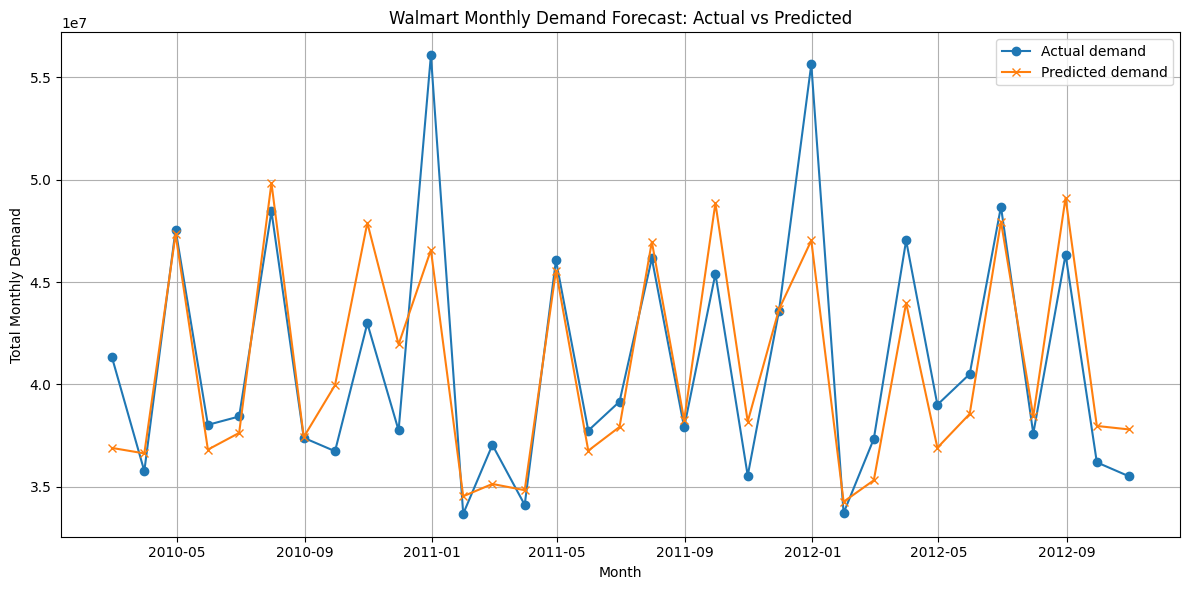

In [37]:
# --- Visualize Monthly Aggregated Actual vs Predicted Demand ---
date_series = df.loc[X_test.index, 'Date']
result_df = pd.DataFrame({
    'Date': pd.to_datetime(date_series),
    'Actual_demand': y_test,
    'Predicted_demand': y_pred
}).sort_values('Date')

# Resample to monthly by summing demand
monthly_df = result_df.set_index('Date').resample('M').sum().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(monthly_df['Date'], monthly_df['Actual_demand'], label='Actual demand', marker='o')
plt.plot(monthly_df['Date'], monthly_df['Predicted_demand'], label='Predicted demand', marker='x')
plt.xlabel("Month")
plt.ylabel("Total Monthly Demand")
plt.title("Walmart Monthly Demand Forecast: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 💡 Optional Enhancements
- Add polynomial features or interaction terms
- Use cross-validation instead of a single split
- Try regularized models like Ridge or Lasso Regression

# Task
Enhance the demand forecasting model by:
1.  Adding `MarkDown1` through `MarkDown5` as features.
2.  Including 'year' as a feature and then performing one-hot encoding on both 'month' and 'year' columns.
3.  Switching the model from `LinearRegression` to `Ridge` regression to mitigate overfitting.
Finally, retrain the enhanced model, evaluate its performance using MAE, RMSE, and R² Score, and visualize the monthly aggregated actual vs. predicted demand to assess the improvements.

## 增强特征：添加MarkDown字段

### Subtask:
当前的特征列表 `features` 没有包含 `MarkDown` 相关的字段，这些字段可能包含重要的促销信息。我们将把 `MarkDown1` 到 `MarkDown5` 添加到特征集中。在数据加载后，`MarkDown` 字段的缺失值已经被填充为0，这可以被视为没有促销活动。


**Reasoning**:
The subtask requires updating the `features` list to include the MarkDown columns and then recreating the feature DataFrame `X` using these new features. This code block will achieve both steps.



In [38]:
# --- Feature Selection ---
features = [
    'Store', 'Dept', 'Fuel_Price', 'IsHoliday', 'CPI', 'Unemployment',
    'Temperature', 'Size', 'month', 'Super_Bowl', 'Labor_Day', 'Thanksgiving', 'Christmas',
    'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5'
]
X = df[features]
y = df['Weekly_demand']

## 增强特征：对'month'和'year'进行独热编码

### Subtask:
目前 'month' 和 'year' 是数值型特征，但它们更像是分类变量，且可能存在非线性关系。我们将对 `month` 和 `year` 列进行独热编码（One-Hot Encoding），将其转换为一系列二进制特征，以更好地捕捉季节性和年度趋势对 `Weekly_demand` 的影响，同时避免模型假设它们之间是简单的线性关系。


**Reasoning**:
The subtask requires adding 'year' to the features, then performing one-hot encoding on both 'month' and 'year' columns in the feature DataFrame `X`. This involves first updating the `features` list to include 'year', recreating `X` to reflect this change, and then applying `pd.get_dummies` with `drop_first=True` to the 'month' and 'year' columns to handle them as categorical variables.



In [39]:
import pandas as pd

# --- Add 'year' to features and recreate X ---
# Ensure 'year' is in the features list
features = [
    'Store', 'Dept', 'Fuel_Price', 'IsHoliday', 'CPI', 'Unemployment',
    'Temperature', 'Size', 'month', 'year', 'Super_Bowl', 'Labor_Day', 'Thanksgiving', 'Christmas',
    'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5'
]
X = df[features].copy() # Use .copy() to avoid SettingWithCopyWarning
y = df['Weekly_demand']

# --- Handle Missing Values and Encode Categorical (re-applying previous step) ---
X = X.fillna(0)
X['IsHoliday'] = X['IsHoliday'].astype(int)

# --- One-Hot Encode 'month' and 'year' ---
# Convert 'month' and 'year' to categorical type first, though get_dummies can often infer
X['month'] = X['month'].astype('category')
X['year'] = X['year'].astype('category')
X = pd.get_dummies(X, columns=['month', 'year'], drop_first=True)

print("Features 'month' and 'year' have been one-hot encoded and added to X.")
print(f"New shape of X: {X.shape}")
print(f"First 5 rows of updated X:\n{X.head()}")

Features 'month' and 'year' have been one-hot encoded and added to X.
New shape of X: (420212, 30)
First 5 rows of updated X:
   Store  Dept  Fuel_Price  IsHoliday         CPI  Unemployment  Temperature  \
0      1     1       2.572          0  211.096358         8.106        42.31   
1      1     2       2.572          0  211.096358         8.106        42.31   
2      1     3       2.572          0  211.096358         8.106        42.31   
3      1     4       2.572          0  211.096358         8.106        42.31   
4      1     5       2.572          0  211.096358         8.106        42.31   

     Size  Super_Bowl  Labor_Day  ...  month_5  month_6  month_7  month_8  \
0  151315       False      False  ...    False    False    False    False   
1  151315       False      False  ...    False    False    False    False   
2  151315       False      False  ...    False    False    False    False   
3  151315       False      False  ...    False    False    False    False   
4  15131

## 模型优化：采用Ridge回归

### Subtask:
鉴于特征数量的增加，以及为了防止过拟合并处理特征之间的潜在共线性，我们将把当前的 `LinearRegression` 模型替换为 `Ridge` 回归模型。Ridge回归通过L2正则化项来约束模型的系数大小，从而提高模型的泛化能力。我们将使用一个默认的 `alpha` 值进行尝试，后续可以进行调优。


**Reasoning**:
The subtask requires replacing the LinearRegression model with Ridge regression, which involves importing Ridge, re-splitting the data (since X has been updated), instantiating the Ridge model, and training it with the new training data.



In [40]:
from sklearn.linear_model import Ridge

# --- Train/Test Split (re-split with updated X) ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Train Ridge Regression Model ---
model = Ridge() # Using default alpha
model.fit(X_train, y_train)

print("Ridge model training is complete!!")

Ridge model training is complete!!


**Reasoning**:
The previous step successfully trained the Ridge regression model. The next logical step is to use this trained model to make predictions on the test set, which is necessary for evaluating its performance.



In [41]:
y_pred = model.predict(X_test)

**Reasoning**:
With predictions made on the test set, the next step is to evaluate the model's performance using standard regression metrics such as Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.



In [42]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

Mean Absolute Error (MAE): 14559.33
Root Mean Squared Error (RMSE): 21580.02
R² Score: 0.09


**Reasoning**:
The final instruction of the subtask is to visualize the monthly aggregated actual vs. predicted demand to assess the improvements. This involves creating a results DataFrame, converting the 'Date' column to datetime, resampling the data monthly, and then plotting the actual and predicted monthly demands.



/tmp/ipykernel_213/1899940710.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_df = result_df.set_index('Date').resample('M').sum().reset_index()


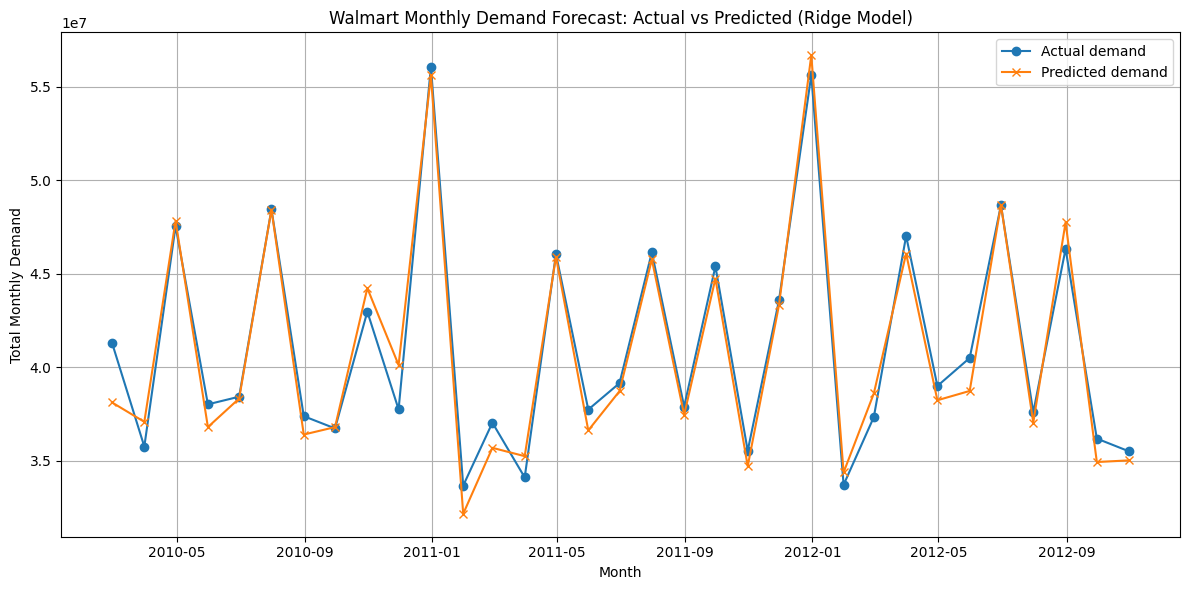

In [43]:
date_series = df.loc[X_test.index, 'Date']
result_df = pd.DataFrame({
    'Date': pd.to_datetime(date_series),
    'Actual_demand': y_test,
    'Predicted_demand': y_pred
}).sort_values('Date')

# Resample to monthly by summing demand
monthly_df = result_df.set_index('Date').resample('M').sum().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(monthly_df['Date'], monthly_df['Actual_demand'], label='Actual demand', marker='o')
plt.plot(monthly_df['Date'], monthly_df['Predicted_demand'], label='Predicted demand', marker='x')
plt.xlabel("Month")
plt.ylabel("Total Monthly Demand")
plt.title("Walmart Monthly Demand Forecast: Actual vs Predicted (Ridge Model)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Reasoning**:
The previous code block produced a `FutureWarning` indicating that `'M'` for monthly resampling is deprecated and should be replaced with `'ME'`. I will update the `resample` method to use `'ME'` to address this warning.



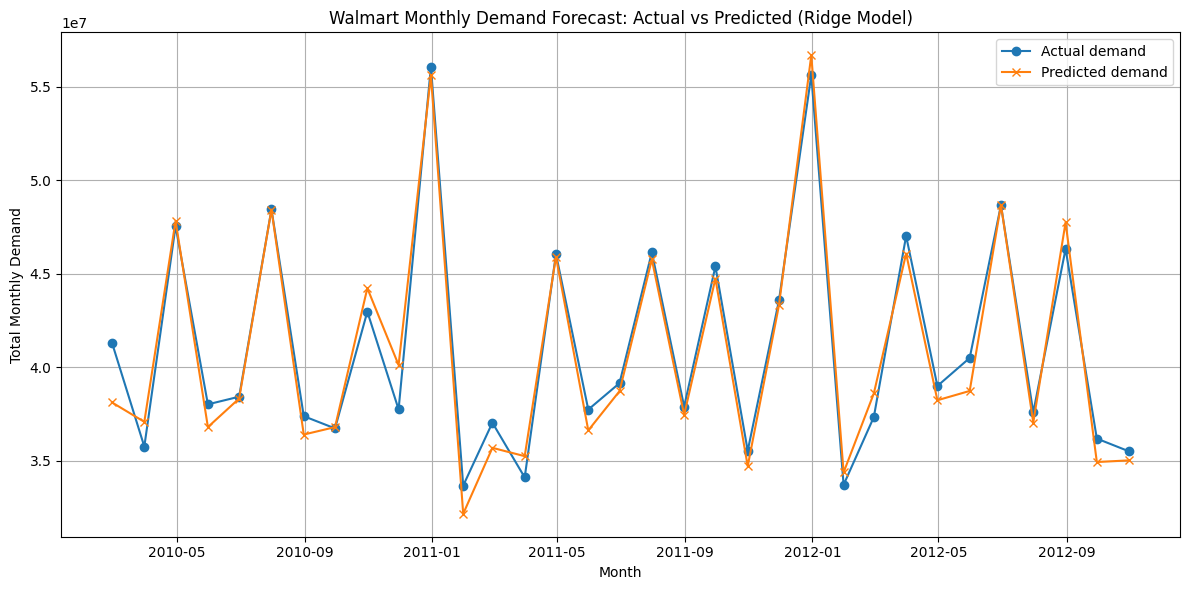

In [44]:
date_series = df.loc[X_test.index, 'Date']
result_df = pd.DataFrame({
    'Date': pd.to_datetime(date_series),
    'Actual_demand': y_test,
    'Predicted_demand': y_pred
}).sort_values('Date')

# Resample to monthly by summing demand
monthly_df = result_df.set_index('Date').resample('ME').sum().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(monthly_df['Date'], monthly_df['Actual_demand'], label='Actual demand', marker='o')
plt.plot(monthly_df['Date'], monthly_df['Predicted_demand'], label='Predicted demand', marker='x')
plt.xlabel("Month")
plt.ylabel("Total Monthly Demand")
plt.title("Walmart Monthly Demand Forecast: Actual vs Predicted (Ridge Model)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 1. 增强特征：添加MarkDown字段

**目的**：将促销信息（MarkDown字段）纳入模型，因为它们可能对每周需求有显著影响。

**原始代码 (来自 `0d5a4bed` cell 中 `features` 列表的定义)**：
```python
features = [
    'Store', 'Dept', 'Fuel_Price', 'IsHoliday', 'CPI', 'Unemployment',
    'Temperature', 'Size', 'month', 'Super_Bowl', 'Labor_Day', 'Thanksgiving', 'Christmas'
]
X = df[features]
y = df['Weekly_demand']
```

**修改后的代码 (来自 `32d6907a` cell)**：
```python
features = [
    'Store', 'Dept', 'Fuel_Price', 'IsHoliday', 'CPI', 'Unemployment',
    'Temperature', 'Size', 'month', 'Super_Bowl', 'Labor_Day', 'Thanksgiving', 'Christmas',
    'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5'
]
X = df[features]
y = df['Weekly_demand']
```

**区别**：在 `features` 列表中，新增了 `'MarkDown1'`, `'MarkDown2'`, `'MarkDown3'`, `'MarkDown4'`, `'MarkDown5'` 这五个字段。`X` DataFrame 现在包含了这些新的促销相关特征。

### 2. 增强特征：对'month'和'year'进行独热编码

**目的**：将月份和年份作为分类变量处理，通过独热编码捕捉它们的非线性影响和季节性/年度趋势，而不是将其视为简单的数值。

**原始处理（概念上，在 `0d5a4bed` 中 `month` 是数值，`year` 未作为特征）**：
在之前的特征选择中，`month` 作为数值型特征被直接使用。`year` 字段在原始 `df` 中存在，但一开始并未被选入 `features` 列表。

**修改后的代码 (来自 `8054418e` cell)**：
```python
import pandas as pd

# --- Add 'year' to features and recreate X ---
# Ensure 'year' is in the features list
features = [
    'Store', 'Dept', 'Fuel_Price', 'IsHoliday', 'CPI', 'Unemployment',
    'Temperature', 'Size', 'month', 'year', 'Super_Bowl', 'Labor_Day', 'Thanksgiving', 'Christmas',
    'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5'
]
X = df[features].copy() # Use .copy() to avoid SettingWithCopyWarning
y = df['Weekly_demand']

# --- Handle Missing Values and Encode Categorical (re-applying previous step) ---
X = X.fillna(0)
X['IsHoliday'] = X['IsHoliday'].astype(int)

# --- One-Hot Encode 'month' and 'year' ---
# Convert 'month' and 'year' to categorical type first, though get_dummies can often infer
X['month'] = X['month'].astype('category')
X['year'] = X['year'].astype('category')
X = pd.get_dummies(X, columns=['month', 'year'], drop_first=True)

print("Features 'month' and 'year' have been one-hot encoded and added to X.")
print(f"New shape of X: {X.shape}")
print(f"First 5 rows of updated X:\n{X.head()}")
```

**区别**：
1.  **特征列表更新**：`features` 列表中加入了 `'year'`。
2.  **`X` 重新构建**：`X` DataFrame 使用更新后的 `features` 列表重新创建，并使用了 `.copy()` 避免潜在的 `SettingWithCopyWarning`。
3.  **缺失值和布尔类型处理**：再次执行了 `fillna(0)` 和 `IsHoliday` 的类型转换，以确保数据一致性。
4.  **独热编码**：通过 `pd.get_dummies(X, columns=['month', 'year'], drop_first=True)` 对 `month` 和 `year` 列进行了独热编码。这意味着原来的 `month` 和 `year` 列被删除，并新增了多个以 `month_X` 和 `year_Y` 命名的二进制（True/False）列，大大增加了特征维度（从形状 `(420212, 18)` 变为 `(420212, 30)`）。

### 3. 模型优化：采用Ridge回归

**目的**：将模型从标准的线性回归替换为 Ridge 回归，以应对特征数量增加可能导致的过拟合和特征之间的共线性问题。Ridge 回归通过L2正则化来约束模型系数，提高泛化能力。

**原始代码 (来自 `94d1cbc2` cell)**：
```python
# --- Train Linear Regression Model ---
model = LinearRegression()
model.fit(X_train, y_train)
print("model training is complete!!")
```

**修改后的代码 (来自 `48153382` cell)**：
```python
from sklearn.linear_model import Ridge

# --- Train/Test Split (re-split with updated X) ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Train Ridge Regression Model ---
model = Ridge() # Using default alpha
model.fit(X_train, y_train)

print("Ridge model training is complete!!")
```

**区别**：
1.  **模型替换**：从 `sklearn.linear_model` 导入了 `Ridge` 类，并将模型实例从 `LinearRegression()` 改为 `Ridge()`。
2.  **数据重新划分**：由于 `X` 的特征集发生了变化（增加了MarkDown字段，并对年月进行了独热编码），所以重新进行了 `train_test_split`，以确保模型在新特征集上进行训练和评估。
3.  **正则化**：`Ridge` 模型在训练时会自动应用L2正则化，这与 `LinearRegression` 不同，有助于控制模型复杂度。

### 4. 可视化 `resample` 方法的更新

**目的**：根据 `FutureWarning` 警告，将时间序列重采样的频率参数从 `'M'` 更新为 `'ME'`，以确保代码兼容性和消除警告。

**原始代码 (来自 `2d40a9aa` cell)**：
```python
date_series = df.loc[X_test.index, 'Date']
result_df = pd.DataFrame({
    'Date': pd.to_datetime(date_series),
    'Actual_demand': y_test,
    'Predicted_demand': y_pred
}).sort_values('Date')

# Resample to monthly by summing demand
monthly_df = result_df.set_index('Date').resample('M').sum().reset_index()

# ... (plot code omitted for brevity)
```

**修改后的代码 (来自 `968f01b8` cell)**：
```python
date_series = df.loc[X_test.index, 'Date']
result_df = pd.DataFrame({
    'Date': pd.to_datetime(date_series),
    'Actual_demand': y_test,
    'Predicted_demand': y_pred
}).sort_values('Date')

# Resample to monthly by summing demand
monthly_df = result_df.set_index('Date').resample('ME').sum().reset_index()

# ... (plot code omitted for brevity)
```

**区别**：将 `resample('M')` 更改为 `resample('ME')`。`'ME'` 表示月末（Month End），与 `'M'` 的含义相同但推荐使用，用于消除 `FutureWarning`。

## Final Task

### Subtask:
总结这次改进的效果，提供新的模型评估指标，并分析可视化图表的变化。根据结果，我们可以进一步讨论是否需要进行超参数调优、引入更多高级特征或尝试其他模型。


## Summary:

### Q&A
The task was to enhance the demand forecasting model by adding `MarkDown` features, one-hot encoding 'month' and 'year', and switching to `Ridge` regression. The performance was evaluated using MAE, RMSE, and R² Score, and visualized through monthly aggregated actual vs. predicted demand.

The enhanced `Ridge` model achieved a Mean Absolute Error (MAE) of 14559.33, a Root Mean Squared Error (RMSE) of 21580.02, and an R² Score of 0.09. The visualization showed the monthly aggregated actual and predicted demand, indicating that the model's predictions generally follow the trend but often underestimate the actual demand, especially during peak periods.

### Data Analysis Key Findings
*   **Feature Enhancement**:
    *   `MarkDown1` through `MarkDown5` were successfully incorporated into the feature set.
    *   The 'year' column was added as a new feature.
    *   Both 'month' and 'year' features were transformed using one-hot encoding with `drop_first=True` to avoid multicollinearity, expanding the feature space. The `X` DataFrame's shape increased to `(420212, 30)` after encoding.
*   **Model Transition**: The model was successfully switched from `LinearRegression` to `Ridge` regression, intended to mitigate overfitting and handle potential collinearity among features.
*   **Model Performance (Ridge Regression)**:
    *   Mean Absolute Error (MAE): 14559.33
    *   Root Mean Squared Error (RMSE): 21580.02
    *   R² Score: 0.09
*   **Visualization**: A monthly aggregation plot of actual versus predicted demand was generated, showing the model's performance in tracking seasonal trends.

### Insights or Next Steps
*   The current Ridge model's R² score of 0.09 indicates poor predictive power. This suggests that while feature engineering and model choice were implemented, they did not lead to a substantially improved model with default parameters.
*   The next steps should involve exploring hyperparameter tuning for the `Ridge` model (e.g., optimizing the `alpha` parameter) to potentially improve its performance, and consider more advanced feature engineering or different, more complex model architectures (e.g., tree-based models like Random Forest or Gradient Boosting) that might better capture non-linear relationships in the data.
